In [1]:
import os
import glob


data_root = "/data/shared/rc-cars/"
mmdet_root = "../third_party/mmdetection"
mmseg_root = "../third_party/mmsegmentation"

## Dataset visualization

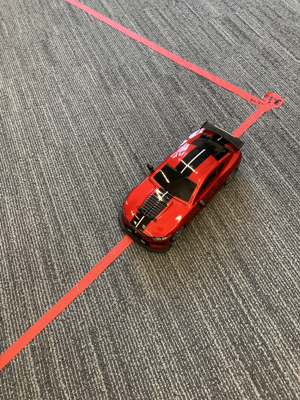

In [25]:
from PIL import Image, ImageOps

sample_img_path = os.path.join(data_root, "images", "ddbfb463-IMG_7999.JPG")

# load image
img = Image.open(sample_img_path)
img = ImageOps.exif_transpose(img)  # do not transpose automatically

# scale to a manageable size
rescale = True
if rescale:
    base_width = 300
    wpercent = (base_width / float(img.size[0]))
    hsize = int((float(img.size[1]) * float(wpercent)))
    img = img.resize((base_width, hsize), Image.BICUBIC)

# display the image with jupyter's builtin display
display(img)

In [17]:
import ExifTags

try:
    image=Image.open(sample_img_path)
    if hasattr(image, '_getexif'): # only present in JPEGs
        for orientation in ExifTags.TAGS.keys(): 
            if ExifTags.TAGS[orientation]=='Orientation':
                break 
        e = image._getexif()       # returns None if no EXIF data
        if e is not None:
            exif=dict(e.items())
            orientation = exif[orientation] 

            if orientation == 3:   image = image.transpose(Image.ROTATE_180)
            elif orientation == 6: image = image.transpose(Image.ROTATE_270)
            elif orientation == 8: image = image.transpose(Image.ROTATE_90)

    image.thumbnail((THUMB_WIDTH , THUMB_HIGHT), Image.ANTIALIAS)
    image.save(os.path.join(path,fileName))

except:
    traceback.print_exc()

ModuleNotFoundError: No module named 'ExifTags'

In [9]:
sample_img_path

'/data/shared/rc-cars/images/ddbfb463-IMG_7999.JPG'

## Bounding box detection algorithm

## Instance segmentation algorithm

In [ ]:
# Choose to use a config
config = 'configs/rtmdet/rtmdet_tiny_1xb4-20e_balloon.py'
# Setup a checkpoint file to load
checkpoint = glob.glob('./work_dirs/rtmdet_tiny_1xb4-20e_balloon/best_coco*.pth')[0]

# Set the device to be used for evaluation
device = 'cuda:0'

# Initialize the DetInferencer
inferencer = DetInferencer(config, checkpoint, device)

# Use the detector to do inference
img = './data/balloon/val/4838031651_3e7b5ea5c7_b.jpg'
result = inferencer(img, out_dir='./output')